# Clase 08 — Random Forest

**Somos el equipo de Risk de Mercado Pago.** El 3% de las transacciones son fraude. No detectar un fraude cuesta el monto de la transacción; frenar una legítima genera mala experiencia al cliente.

**Pregunta:** ¿qué transacciones detener antes de que se cierren para minimizar el fraude no detectado?

Comparamos CART vs Random Forest y tuneamos con cross-validation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
VERDE, CORAL = "#00A650", "#FF6F61"


## 1. Carga

In [2]:
df = pd.read_csv("transacciones_mercadopago.csv")
print(df.shape)
df.head()

(5000, 12)


,monto,hora_del_dia,dispositivo,antiguedad_cuenta_dias,ubicacion_nueva,n_tx_ultimas_24h,n_tx_ultimos_7d,intentos_pin_fallidos_24h,categoria_comercio,dia_de_la_semana,monto_vs_promedio_cliente,es_fraude
0,1949.63,22,mobile_android,476,False,3,5,0,supermercado,dom,0.97,0
1,3954.93,11,mobile_ios,761,False,2,6,0,gastronomia,lun,1.16,0
2,1592.71,13,mobile_android,956,False,0,4,0,electronicos,jue,1.34,0
3,15867.28,11,mobile_android,435,False,0,2,0,viajes,vie,1.27,0
4,1372.02,9,web,1483,False,3,6,0,gastronomia,sab,0.45,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   monto                      5000 non-null   float64
 1   hora_del_dia               5000 non-null   int64  
 2   dispositivo                5000 non-null   object 
 3   antiguedad_cuenta_dias     5000 non-null   int64  
 4   ubicacion_nueva            5000 non-null   bool   
 5   n_tx_ultimas_24h           5000 non-null   int64  
 6   n_tx_ultimos_7d            5000 non-null   int64  
 7   intentos_pin_fallidos_24h  5000 non-null   int64  
 8   categoria_comercio         5000 non-null   object 
 9   dia_de_la_semana           5000 non-null   object 
 10  monto_vs_promedio_cliente  5000 non-null   float64
 11  es_fraude                  5000 non-null   int64  
dtypes: bool(1), float64(2), int64(6), object(3)
memory usage: 434.7+ KB


## 2. EDA

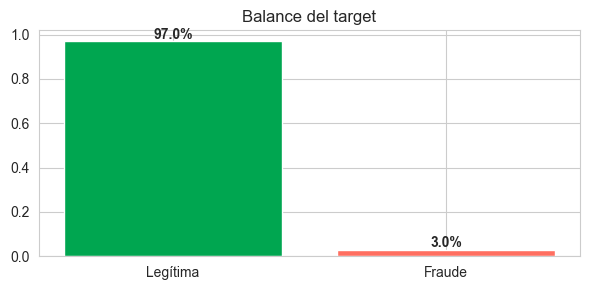

In [4]:
balance = df["es_fraude"].value_counts(normalize=True).rename({0: "Legítima", 1: "Fraude"})

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(balance.index, balance.values, color=[VERDE, CORAL])
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_title("Balance del target")
plt.tight_layout()
plt.show()

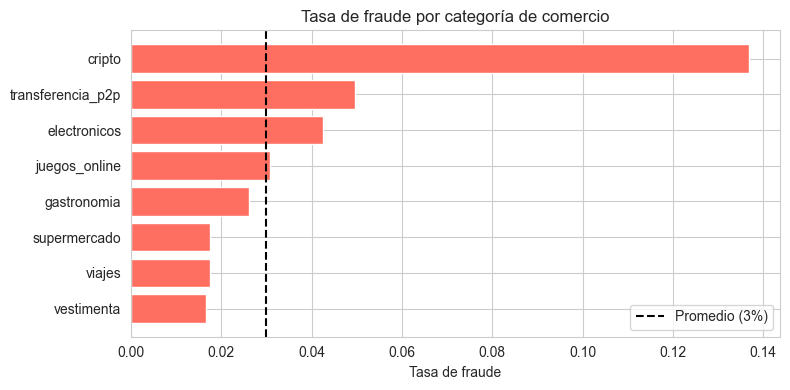

In [5]:
tasa = df.groupby("categoria_comercio")["es_fraude"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tasa.index[::-1], tasa.values[::-1], color=CORAL)
ax.axvline(0.03, color="black", linestyle="--", label="Promedio (3%)")
ax.set_xlabel("Tasa de fraude")
ax.set_title("Tasa de fraude por categoría de comercio")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preparación

One-hot encoding de categóricas, split estratificado 70/30.

In [6]:
df_m = pd.get_dummies(
    df,
    columns=["dispositivo", "categoria_comercio", "dia_de_la_semana"],
    drop_first=True,
)
df_m["ubicacion_nueva"] = df_m["ubicacion_nueva"].astype(int)

features = [c for c in df_m.columns if c != "es_fraude"]
X = df_m[features]
y = df_m["es_fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"% fraude train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Train: 3500 | Test: 1500
% fraude train: 3.00% | test: 3.00%


## 4. CART (baseline)

In [7]:
cart = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)
cart.fit(X_train, y_train)

y_pred_cart = cart.predict(X_test)

print(classification_report(y_test, y_pred_cart, target_names=["Legítima", "Fraude"]))

              precision    recall  f1-score   support

    Legítima       1.00      0.85      0.92      1455
      Fraude       0.15      0.87      0.26        45

    accuracy                           0.85      1500
   macro avg       0.57      0.86      0.59      1500
weighted avg       0.97      0.85      0.90      1500



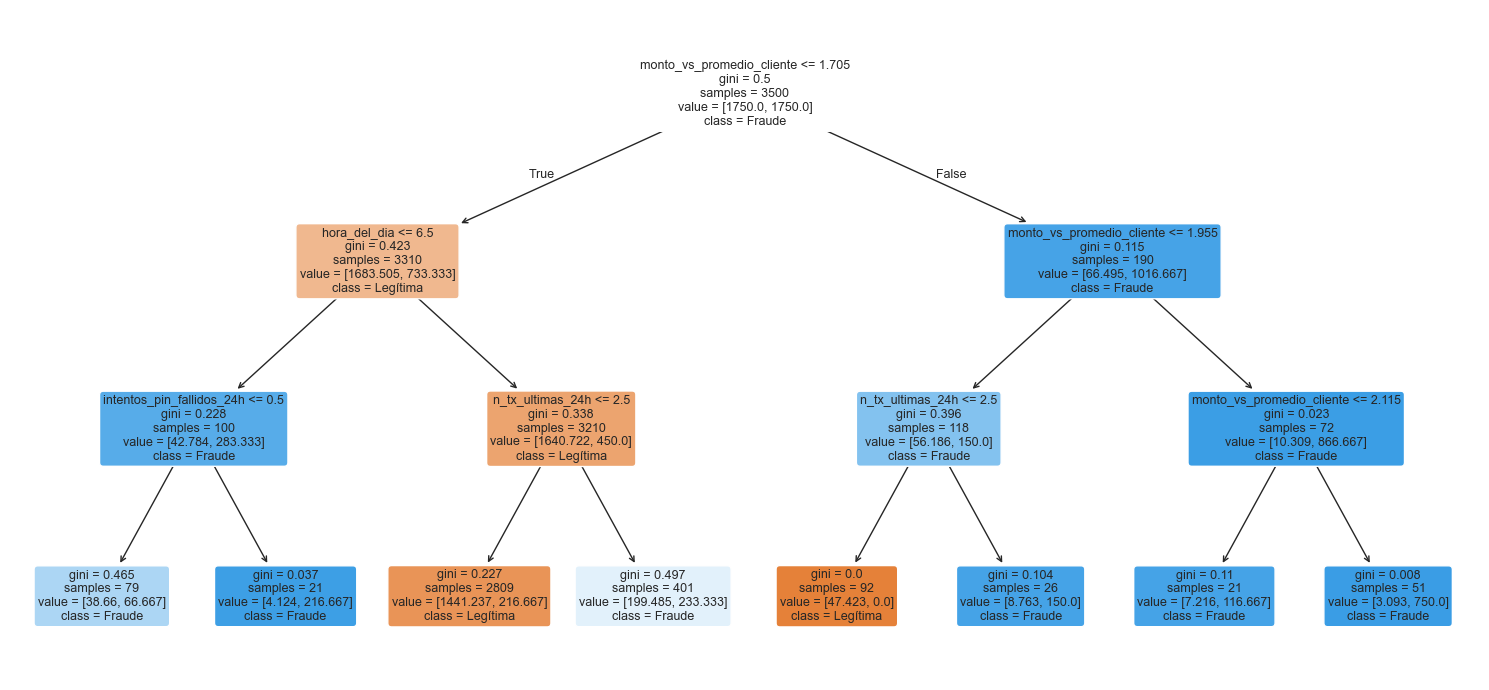

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    cart,
    feature_names=features,
    class_names=["Legítima", "Fraude"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.tight_layout()
plt.show()

## 5. Random Forest

Random Forest = **Bagging** (Bootstrap Aggregating): muchos árboles entrenados con muestras bootstrap + selección aleatoria de features en cada split.

In [9]:
rf_default = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf_default.fit(X_train, y_train)

y_pred_rf_def = rf_default.predict(X_test)

print(classification_report(y_test, y_pred_rf_def, target_names=["Legítima", "Fraude"]))

              precision    recall  f1-score   support

    Legítima       0.98      1.00      0.99      1455
      Fraude       0.94      0.33      0.49        45

    accuracy                           0.98      1500
   macro avg       0.96      0.67      0.74      1500
weighted avg       0.98      0.98      0.97      1500



Recall del fraude más bajo que CART. El default no es óptimo — lo corregimos tuneando hiperparámetros en la próxima sección.

## 6. GridSearchCV + StratifiedKFold

In [10]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1),
    param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")
print(f"Mejor recall en CV: {grid.best_score_:.3f}")

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Mejor recall en CV: 0.657


In [11]:
rf_best = grid.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["Legítima", "Fraude"]))

              precision    recall  f1-score   support

    Legítima       0.99      0.99      0.99      1455
      Fraude       0.69      0.73      0.71        45

    accuracy                           0.98      1500
   macro avg       0.84      0.86      0.85      1500
weighted avg       0.98      0.98      0.98      1500



## 7. Importancia de variables

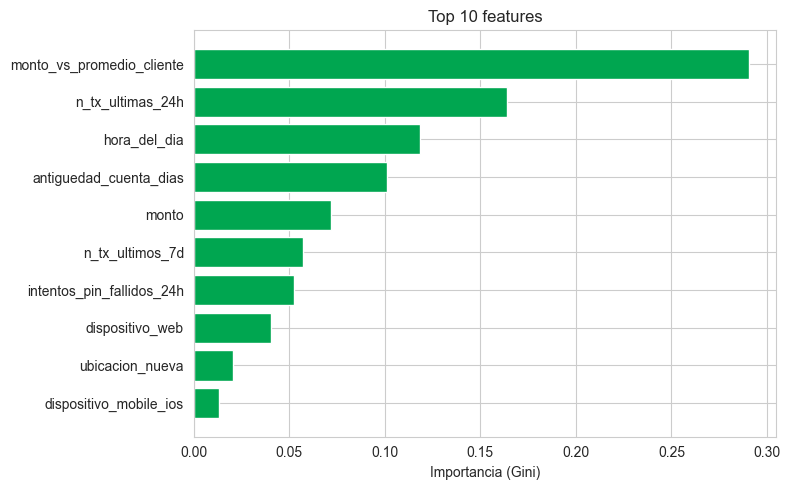

In [12]:
imp = pd.Series(rf_best.feature_importances_, index=features).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index[::-1], imp.values[::-1], color=VERDE)
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 10 features")
plt.tight_layout()
plt.show()

## 8. Comparación final

In [13]:
def metricas(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Accuracy": rep["accuracy"],
        "Precision (Fraude)": rep["1"]["precision"],
        "Recall (Fraude)": rep["1"]["recall"],
    }

tabla = pd.DataFrame({
    "CART": metricas(y_test, y_pred_cart),
    "RF default": metricas(y_test, y_pred_rf_def),
    "RF tuneado": metricas(y_test, y_pred_rf),
}).T.round(3)

tabla

,Accuracy,Precision (Fraude),Recall (Fraude)
CART,0.851,0.152,0.867
RF default,0.979,0.938,0.333
RF tuneado,0.982,0.688,0.733


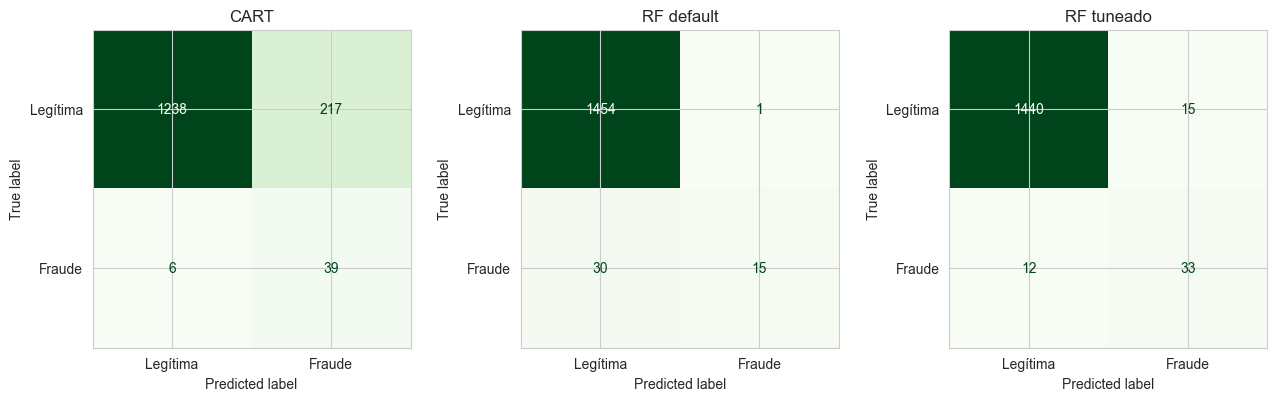

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (titulo, y_pred) in zip(
    axes,
    [("CART", y_pred_cart), ("RF default", y_pred_rf_def), ("RF tuneado", y_pred_rf)],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Legítima", "Fraude"],
        cmap="Greens",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

## 9. Conclusión

**Volviendo a la pregunta:** llevamos a producción el **Random Forest tuneado**. Detecta 3 de cada 4 fraudes (recall 0.73) y mantiene precision aceptable (0.69). El CART era demasiado inclusivo, el RF por defecto demasiado conservador. La diferencia no estuvo en el algoritmo sino en tunear los hiperparámetros con cross-validation.

**Próxima clase:** Boosting — árboles entrenados en secuencia, cada uno corrigiendo los errores del anterior.